# County Feature Correlations With Relative Position Within NRI Risk Group

This notebook uses the curated county feature definitions from `src/housing_climate_risk/modeling/county_relative_ppsf/data.py`, then tests how those features correlate with each county's relative Median PPSF YOY position within its own NRI risk group.


## Setup

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.constrained_layout.use": False, "axes.titlepad": 12, "axes.labelpad": 8})

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent.parent

DB_PATH = ROOT / "data" / "quoll.duckdb"
con = duckdb.connect(str(DB_PATH), read_only=True)

RISK_ORDER = [
    "Very Low",
    "Relatively Low",
    "Relatively Moderate",
    "Relatively High",
    "Very High",
]
RISK_RATING_TO_ORDINAL = {rating: i + 1 for i, rating in enumerate(RISK_ORDER)}

FEATURE_META = {
    "income_median_household_usd": ("Economic", "Income"),
    "insurance_homeowners_pct_income": ("Economic", "Insurance % of Income"),
    "property_taxes_pct_income": ("Economic", "Property Tax % of Income"),
    "utilities_pct_income": ("Economic", "Utilities % of Income"),
    "housing_burden_30pct_plus_share": ("Economic", "Housing Burden"),
    "homeownership_cost_pct_income": ("Economic", "Homeownership Cost Share"),
    "unemployment_rate_pct": ("Economic", "Unemployment"),
    "net_earnings_per_capita": ("Economic", "Net Earnings per Capita"),
    "dividends_interest_rent_per_capita": ("Economic", "Dividends/Interest/Rent per Capita"),
    "transfer_receipts_per_capita": ("Economic", "Transfer Receipts per Capita"),
    "accom_food_wages_pct_total_wages": ("Economic", "Accom. & Food Wages % Total Wages"),
    "net_migration_rate": ("Demographic", "Net Migration Rate"),
    "age_65_plus_share": ("Demographic", "Age >= 65 Years"),
    "disability_share": ("Demographic", "Disability Status"),
    "english_less_than_very_well_share": ("Demographic", "Communication Barrier"),
    "no_broadband_internet_share": ("Demographic", "No Internet Access"),
    "median_ppsf_yoy": ("Housing Market", "Median PPSF YOY"),
    "avg_sale_to_list_yoy": ("Housing Market", "Average Sale-to-List YOY"),
    "homes_sold_yoy": ("Housing Market", "Homes Sold YOY"),
    "inventory_yoy": ("Housing Market", "Inventory YOY"),
    "new_listings_yoy": ("Housing Market", "New Listings YOY"),
    "median_dom_yoy": ("Housing Market", "Median Days on Market YOY"),
    "price_drops_yoy": ("Housing Market", "Price Drops YOY"),
    "temperature_mean_f": ("Climate", "Temperature"),
    "precipitation_mean_inches": ("Climate", "Precipitation"),
}

FEATURE_ORDER = list(FEATURE_META)
FEATURE_LABELS = {feature: label for feature, (_, label) in FEATURE_META.items()}
FEATURE_GROUPS = {feature: group for feature, (group, _) in FEATURE_META.items()}
FEATURES = FEATURE_ORDER

# Exclude Biological, Chemical, Terrorist, Dam/Levee, Other, Toxic (same filter as stormhouse)
EXCLUDED_INCIDENT_TYPES = (
    "'Biological', 'Chemical', 'Terrorist', 'Dam/Levee Break', 'Other', 'Toxic Substances'"
)


def q(sql: str) -> pd.DataFrame:
    return con.execute(sql).df()


def quote_ident(value: str) -> str:
    return '"' + str(value).replace('"', '""') + '"'


def num(column: str, alias: str | None = None) -> str:
    alias = alias or column
    quoted = quote_ident(column)
    return f"try_cast(replace(nullif(trim(cast({quoted} AS VARCHAR)), ''), ',', '') AS DOUBLE) AS {quote_ident(alias)}"


def ten_year_avg_table_sql(table_name: str, select_parts: list[str]) -> str:
    """Average feature values across the last 10 calendar years."""
    return f"""
        SELECT
            lpad(fips, 5, '0') AS fips,
            {",\n            ".join(select_parts)}
        FROM mart.{quote_ident(table_name)}
        WHERE year >= (SELECT max(year) FROM mart.{quote_ident(table_name)}) - 9
        GROUP BY fips
    """


def weighted_midpoint(frame: pd.DataFrame, bins: list[tuple[str, float]]) -> pd.Series:
    numer = pd.Series(0.0, index=frame.index)
    denom = pd.Series(0.0, index=frame.index)
    for column, midpoint in bins:
        values = pd.to_numeric(frame[column], errors="coerce")
        valid = values.notna() & values.ge(0)
        numer = numer.add(values.where(valid, 0) * midpoint, fill_value=0)
        denom = denom.add(values.where(valid, 0), fill_value=0)
    return numer.where(denom.gt(0)).div(denom.where(denom.gt(0)))


def mean_available(frame: pd.DataFrame, columns: list[str]) -> pd.Series:
    return frame[columns].apply(pd.to_numeric, errors="coerce").mean(axis=1, skipna=True)


DB_PATH

WindowsPath('C:/Users/kenny/Data Science Projects/housing-predict/data/quoll.duckdb')

## NRI Risk Ratings

In [2]:
nri = q("""
    SELECT
        lpad(fips, 5, '0') AS fips,
        STATEABBRV AS state_abbrev,
        COUNTY AS county_name,
        risk_rating
    FROM mart.nri_county_risk
    WHERE fips IS NOT NULL
      AND risk_rating IN ('Very Low', 'Relatively Low', 'Relatively Moderate',
                          'Relatively High', 'Very High')
""")
nri["risk_rating"] = pd.Categorical(nri["risk_rating"], categories=RISK_ORDER, ordered=True)

display(nri["risk_rating"].value_counts().sort_index().to_frame("counties"))

,counties
risk_rating,
Very Low,1345
Relatively Low,1200
Relatively Moderate,420
Relatively High,162
Very High,17


## FEMA Disaster Events

One row per county × disaster declaration. We keep only county-level declarations (5-digit FIPS) and exclude incident types that are non-climate.

In [3]:
events = q(f"""
    SELECT
        lpad(fips, 5, '0') AS fips,
        disasterNumber AS disaster_number,
        incidentType AS incident_type,
        declarationTitle AS declaration_title,
        incident_begin_date,
        incident_end_date,
        EXTRACT(year FROM incident_begin_date) AS event_start_year,
        EXTRACT(year FROM incident_end_date)   AS event_end_year
    FROM mart.fema_disaster_declarations
    WHERE fips IS NOT NULL
      AND length(fips) = 5
      AND right(fips, 3) != '000'
      AND incident_begin_date IS NOT NULL
      AND incident_end_date IS NOT NULL
      AND incidentType NOT IN ({EXCLUDED_INCIDENT_TYPES})
""")

events["event_start_year"] = events["event_start_year"].astype(int)
events["event_end_year"] = events["event_end_year"].astype(int)

# Attach NRI risk rating
events = events.merge(nri[["fips", "risk_rating"]], on="fips", how="inner")

print(f"County-events: {len(events):,}")
print(f"Distinct counties: {events['fips'].nunique():,}")
print(f"Disaster year range: {events['event_start_year'].min()} – {events['event_start_year'].max()}")
events[["incident_type", "disaster_number"]].groupby("incident_type").count().rename(
    columns={"disaster_number": "county_declarations"}
).sort_values("county_declarations", ascending=False).head(15)

County-events: 57,885
Distinct counties: 3,129
Disaster year range: 1959 – 2026


,county_declarations
incident_type,
Severe Storm,19477
Hurricane,12425
Flood,10582
Snowstorm,3634
Fire,3508
Severe Ice Storm,2952
Tornado,1601
Drought,1223
Tropical Storm,987


## Define Annual Event Windows

| Window | Pre-event | Post-event |
|--------|-----------|------------|
| W1 | 1 year before event start | 3 years after event end |
| W2 | 1 year before event start | 5 years after event end |

Year range: `[event_start_year - 1, event_end_year + N]`.

In [4]:
events["w1_start_year"] = events["event_start_year"] - 1
events["w1_end_year"]   = events["event_end_year"] + 3
events["w2_start_year"] = events["event_start_year"] - 1
events["w2_end_year"]   = events["event_end_year"] + 5

print("W1 window length distribution (years):")
display((events["w1_end_year"] - events["w1_start_year"] + 1).describe())
print("\nW2 window length distribution (years):")
display((events["w2_end_year"] - events["w2_start_year"] + 1).describe())

W1 window length distribution (years):


count    57885.000000
mean         5.038041
std          0.199346
min          5.000000
25%          5.000000
50%          5.000000
75%          5.000000
max         19.000000
dtype: float64


W2 window length distribution (years):


count    57885.000000
mean         7.038041
std          0.199346
min          7.000000
25%          7.000000
50%          7.000000
75%          7.000000
max         21.000000
dtype: float64

## Monthly PPSF YOY

Load raw monthly Redfin `MEDIAN_PPSF_YOY` — no annual pre-aggregation. The event-window join uses the calendar year of each monthly record.

In [5]:
redfin_monthly = q("""
    SELECT
        lpad(fips, 5, '0') AS fips,
        EXTRACT(year FROM period_begin) AS year,
        try_cast(
            replace(nullif(trim(cast(MEDIAN_PPSF_YOY AS VARCHAR)), ''), ',', '')
            AS DOUBLE) AS median_ppsf_yoy
    FROM mart.redfin_county_monthly
    WHERE fips IS NOT NULL
      AND period_begin IS NOT NULL
      AND coalesce(property_type, PROPERTY_TYPE_1) = 'All Residential'
      AND MEDIAN_PPSF_YOY IS NOT NULL
""")
redfin_monthly["year"] = redfin_monthly["year"].astype(int)
redfin_monthly["median_ppsf_yoy"] = pd.to_numeric(redfin_monthly["median_ppsf_yoy"], errors="coerce")
redfin_monthly = redfin_monthly.dropna(subset=["median_ppsf_yoy"])

print(f"Monthly rows: {len(redfin_monthly):,}")
print(f"Counties: {redfin_monthly['fips'].nunique():,}")
print(f"Year range: {redfin_monthly['year'].min()} – {redfin_monthly['year'].max()}")
redfin_monthly.head()

Monthly rows: 413,090
Counties: 3,035
Year range: 2012 – 2025


,fips,year,median_ppsf_yoy
0,21145,2017,0.007444
1,19105,2023,-0.025484
2,45003,2023,-0.007414
3,50001,2017,-0.110846
4,42057,2024,-0.094665


## Average Monthly PPSF YOY Over Each Event Window

For each county × event, average all monthly `MEDIAN_PPSF_YOY` observations whose calendar year falls inside the window. Require at least 2 monthly observations. Then collapse to one row per county by averaging across events.

In [6]:
import duckdb as _duckdb

_mem = _duckdb.connect()
_mem.register("events_df", events)
_mem.register("redfin_monthly_df", redfin_monthly)


def compute_avg_ppsf(start_col: str, end_col: str) -> pd.DataFrame:
    """One row per county × event: average of monthly PPSF YOY inside the window."""
    return _mem.execute(f"""
        SELECT
            e.fips,
            e.disaster_number,
            e.incident_type,
            e.risk_rating,
            e.event_start_year,
            e.event_end_year,
            e.{start_col} AS window_start_year,
            e.{end_col}   AS window_end_year,
            avg(r.median_ppsf_yoy)  AS avg_ppsf_yoy,
            count(*)                AS months_in_window
        FROM events_df e
        JOIN redfin_monthly_df r
          ON r.fips = e.fips
         AND r.year BETWEEN e.{start_col} AND e.{end_col}
        GROUP BY
            e.fips, e.disaster_number, e.incident_type, e.risk_rating,
            e.event_start_year, e.event_end_year,
            e.{start_col}, e.{end_col}
        HAVING count(*) >= 2
    """).df()


def collapse_to_county(df: pd.DataFrame) -> pd.DataFrame:
    """Average per-event avg_ppsf_yoy values to one row per county."""
    return (
        df.groupby("fips", as_index=False)
        .agg(
            risk_rating=("risk_rating", "first"),
            avg_ppsf_yoy=("avg_ppsf_yoy", "mean"),
            event_count=("disaster_number", "nunique"),
        )
    )


w1_raw = compute_avg_ppsf("w1_start_year", "w1_end_year")
w2_raw = compute_avg_ppsf("w2_start_year", "w2_end_year")

w1 = collapse_to_county(w1_raw)
w2 = collapse_to_county(w2_raw)

for label, raw_df, county_df in [
    ("W1 (pre-1 / post-3)", w1_raw, w1),
    ("W2 (pre-1 / post-5)", w2_raw, w2),
]:
    print(f"\n{label}")
    print(f"  County-events (before collapse): {len(raw_df):,}")
    print(f"  Counties (after collapse):       {len(county_df):,}")
    print(f"  Counties with >1 event averaged: {(county_df['event_count'] > 1).sum():,}")
    display(county_df[["risk_rating", "avg_ppsf_yoy"]].groupby("risk_rating", observed=False)
            .describe()["avg_ppsf_yoy"][["count", "mean", "std", "50%"]])


W1 (pre-1 / post-3)
  County-events (before collapse): 21,223
  Counties (after collapse):       2,852
  Counties with >1 event averaged: 2,611


,count,mean,std,50%
risk_rating,,,,
Very Low,1174.0,3.257607,58.488271,0.188674
Relatively Low,1112.0,0.837066,20.884150,0.090953
Relatively Moderate,393.0,0.086821,0.117063,0.062714
Relatively High,156.0,0.061382,0.026975,0.060635
Very High,17.0,0.068713,0.037904,0.063108



W2 (pre-1 / post-5)
  County-events (before collapse): 24,776
  Counties (after collapse):       2,879
  Counties with >1 event averaged: 2,693


,count,mean,std,50%
risk_rating,,,,
Very Low,1192.0,2.145455,31.274958,0.192925
Relatively Low,1119.0,0.641011,14.663763,0.089749
Relatively Moderate,395.0,0.087595,0.116114,0.063482
Relatively High,156.0,0.062025,0.026848,0.060500
Very High,17.0,0.074887,0.037235,0.070473


## Relative Position Within Risk Group

`relative_position = county_avg_ppsf_yoy − group_median_avg_ppsf_yoy`

Group = NRI risk rating. Counties above the group median have a positive score.

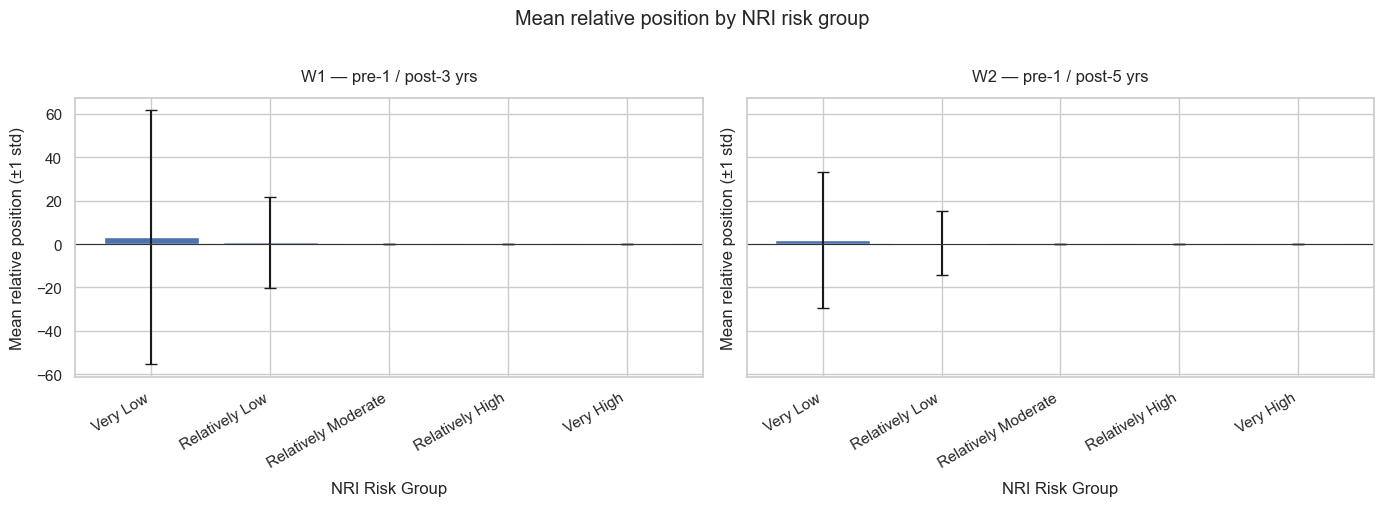

In [7]:
def add_relative_position(df: pd.DataFrame) -> pd.DataFrame:
    group_medians = (
        df.groupby("risk_rating", observed=False)["avg_ppsf_yoy"]
        .median()
        .rename("group_median_ppsf_yoy")
    )
    out = df.merge(group_medians, on="risk_rating", how="left")
    out["relative_position"] = out["avg_ppsf_yoy"] - out["group_median_ppsf_yoy"]
    return out


w1 = add_relative_position(w1)
w2 = add_relative_position(w2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, df, label in [
    (axes[0], w1, "W1 — pre-1 / post-3 yrs"),
    (axes[1], w2, "W2 — pre-1 / post-5 yrs"),
]:
    grouped = df.groupby("risk_rating", observed=False)["relative_position"]
    means = grouped.mean().reindex(RISK_ORDER)
    stds  = grouped.std().reindex(RISK_ORDER)
    ax.bar(range(len(RISK_ORDER)), means, yerr=stds, capsize=4)
    ax.set_xticks(range(len(RISK_ORDER)))
    ax.set_xticklabels(RISK_ORDER, rotation=30, ha="right")
    ax.axhline(0, color="#333", linewidth=0.8)
    ax.set_title(label)
    ax.set_xlabel("NRI Risk Group")
    ax.set_ylabel("Mean relative position (±1 std)")
plt.suptitle("Mean relative position by NRI risk group", y=1.01)
plt.tight_layout()
plt.show()

## Curated County Features

These cells mirror the production definitions in `src/housing_climate_risk/modeling/county_relative_ppsf/data.py` so the within-risk-group analysis uses the same county feature concepts.

### ACS Economic Features

In [8]:
afford_selects = [
    f"avg({num('s2503_owner_occupied_units_occupied_housing_units_household_income_past_12_months_median_household_income_est').rsplit(' AS ', 1)[0]}) AS median_household_income",
    f"avg(CAST({num('s2503_owner_occupied_units_occupied_housing_units_monthly_housing_costs_median_est').rsplit(' AS ', 1)[0]} AS DOUBLE)) AS monthly_housing_costs",
    f"avg({num('median_property_taxes').rsplit(' AS ', 1)[0]}) AS property_taxes_median_annual_usd",
    f"avg({num('dp04_selected_monthly_owner_costs_as_a_pct_of_household_income_housing_units_mortgage_30_0_to_34_9_percent_pct').rsplit(' AS ', 1)[0]}) AS owner_mortgage_30_34_pct",
    f"avg({num('dp04_selected_monthly_owner_costs_as_a_pct_of_household_income_housing_units_mortgage_35_0_percent_or_more_pct').rsplit(' AS ', 1)[0]}) AS owner_mortgage_35_plus_pct",
    f"avg({num('dp04_selected_monthly_owner_costs_as_a_pct_of_household_income_housing_unit_no_mortgage_30_0_to_34_9_percent_pct').rsplit(' AS ', 1)[0]}) AS owner_no_mortgage_30_34_pct",
    f"avg({num('dp04_selected_monthly_owner_costs_as_a_pct_of_household_income_housing_unit_no_mortgage_35_0_percent_or_more_pct').rsplit(' AS ', 1)[0]}) AS owner_no_mortgage_35_plus_pct",
]

electric_bins = [
    ("b25132_monthly_electricity_costs_total_charged_for_electricity_less_than_dollars_50_est", 25),
    ("b25132_monthly_electricity_costs_total_charged_for_electricity_dollars_50_to_dollars_99_est", 75),
    ("b25132_monthly_electricity_costs_total_charged_for_electricity_dollars_100_to_dollars_149_est", 125),
    ("b25132_monthly_electricity_costs_total_charged_for_electricity_dollars_150_to_dollars_199_est", 175),
    ("b25132_monthly_electricity_costs_total_charged_for_electricity_dollars_200_to_dollars_249_est", 225),
    ("b25132_monthly_electricity_costs_total_charged_for_electricity_dollars_250_or_more_est", 275),
]
gas_bins = [
    ("b25133_monthly_gas_costs_total_charged_for_gas_less_than_dollars_25_est", 12.5),
    ("b25133_monthly_gas_costs_total_charged_for_gas_dollars_25_to_dollars_49_est", 37.5),
    ("b25133_monthly_gas_costs_total_charged_for_gas_dollars_50_to_dollars_74_est", 62.5),
    ("b25133_monthly_gas_costs_total_charged_for_gas_dollars_75_to_dollars_99_est", 87.5),
    ("b25133_monthly_gas_costs_total_charged_for_gas_dollars_100_to_dollars_149_est", 125),
    ("b25133_monthly_gas_costs_total_charged_for_gas_dollars_150_or_more_est", 175),
]
water_annual_bins = [
    ("b25134_annual_water_and_sewer_costs_total_charged_for_water_and_sewer_less_than_dollars_125_est", 62.5),
    ("b25134_annual_water_and_sewer_costs_total_charged_for_water_and_sewer_dollars_125_to_dollars_249_est", 187),
    ("b25134_annual_water_and_sewer_costs_total_charged_for_water_and_sewer_dollars_250_to_dollars_499_est", 375),
    ("b25134_annual_water_and_sewer_costs_total_charged_for_water_and_sewer_dollars_500_to_dollars_749_est", 625),
    ("b25134_annual_water_and_sewer_costs_total_charged_for_water_and_sewer_dollars_750_to_dollars_999_est", 875),
    ("b25134_annual_water_and_sewer_costs_total_charged_for_water_and_sewer_dollars_1_000_or_more_est", 1125),
]
fuel_annual_bins = [
    ("b25135_annual_other_fuel_costs_total_charged_for_other_fuels_less_than_dollars_250_est", 125),
    ("b25135_annual_other_fuel_costs_total_charged_for_other_fuels_dollars_250_to_dollars_749_est", 500),
    ("b25135_annual_other_fuel_costs_total_charged_for_other_fuels_dollars_750_or_more_est", 875),
]
insurance_bins = [
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_mortgage_less_than_dollars_100_est", 50),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_mortgage_dollars_100_to_dollars_299_est", 200),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_mortgage_dollars_300_to_dollars_499_est", 400),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_mortgage_dollars_500_to_dollars_799_est", 650),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_mortgage_dollars_800_to_dollars_999_est", 900),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_mortgage_dollars_1000_to_dollars_1499_est", 1250),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_mortgage_dollars_1500_to_dollars_1999_est", 1750),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_mortgage_dollars_2000_to_dollars_2499_est", 2250),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_mortgage_dollars_2500_to_dollars_2999_est", 2750),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_mortgage_dollars_3000_to_dollars_3499_est", 3250),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_mortgage_dollars_3500_to_dollars_3999_est", 3750),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_mortgage_dollars_4000_or_more_est", 4250),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_not_mortgaged_less_than_dollars_100_est", 50),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_not_mortgaged_dollars_100_to_dollars_299_est", 200),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_not_mortgaged_dollars_300_to_dollars_499_est", 400),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_not_mortgaged_dollars_500_to_dollars_799_est", 650),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_not_mortgaged_dollars_800_to_dollars_999_est", 900),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_not_mortgaged_dollars_1000_to_dollars_1499_est", 1250),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_not_mortgaged_dollars_1500_to_dollars_1999_est", 1750),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_not_mortgaged_dollars_2000_to_dollars_2499_est", 2250),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_not_mortgaged_dollars_2500_to_dollars_2999_est", 2750),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_not_mortgaged_dollars_3000_to_dollars_3499_est", 3250),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_not_mortgaged_dollars_3500_to_dollars_3999_est", 3750),
    ("b25141_homeowners_insurance_costs_by_mortgage_status_total_not_mortgaged_dollars_4000_or_more_est", 4250),
]
all_bin_columns = [column for bins in [electric_bins, gas_bins, water_annual_bins, fuel_annual_bins, insurance_bins] for column, _ in bins]
afford_selects.extend(f"avg({num(column).rsplit(' AS ', 1)[0]}) AS {quote_ident(column)}" for column in all_bin_columns)

afford = q(ten_year_avg_table_sql("acs_county_affordability_annual", afford_selects))
for column in afford.columns:
    if column != "fips":
        afford[column] = pd.to_numeric(afford[column], errors="coerce")

afford["income_median_household_usd"] = afford["median_household_income"]
afford["insurance_homeowners_annual_usd"] = weighted_midpoint(afford, insurance_bins)
afford["utilities_monthly_usd"] = (
    weighted_midpoint(afford, electric_bins)
    + weighted_midpoint(afford, gas_bins)
    + weighted_midpoint(afford, water_annual_bins) / 12
    + weighted_midpoint(afford, fuel_annual_bins) / 12
)
afford["housing_burden_30pct_plus_share"] = mean_available(
    afford,
    [
        "owner_mortgage_30_34_pct",
        "owner_mortgage_35_plus_pct",
        "owner_no_mortgage_30_34_pct",
        "owner_no_mortgage_35_plus_pct",
    ],
)
# Define homeownership burden as total annual homeownership cost as a percentage of household income.
# Use S2503 median monthly housing costs which includes mortgage, insurance, taxes, utilities, and HOA fees.
afford["homeownership_cost_annual_usd"] = afford["monthly_housing_costs"] * 12
afford["homeownership_cost_pct_income"] = (
    afford["homeownership_cost_annual_usd"]
    / afford["income_median_household_usd"]
    * 100
)
# Calculate individual cost components as percentage of income
afford["insurance_homeowners_pct_income"] = (
    afford["insurance_homeowners_annual_usd"]
    / afford["income_median_household_usd"]
    * 100
)
afford["property_taxes_pct_income"] = (
    afford["property_taxes_median_annual_usd"]
    / afford["income_median_household_usd"]
    * 100
)
afford["utilities_pct_income"] = (
    (afford["utilities_monthly_usd"] * 12)
    / afford["income_median_household_usd"]
    * 100
)

economic_afford = afford[
    [
        "fips",
        "income_median_household_usd",
        "insurance_homeowners_pct_income",
        "property_taxes_pct_income",
        "utilities_pct_income",
        "housing_burden_30pct_plus_share",
        "homeownership_cost_pct_income",
    ]
]

econ = q(
    ten_year_avg_table_sql(
        "acs_county_economic_annual",
        [
            f"avg({num('dp03_civilian_labor_force_unemployment_rate_pct').rsplit(' AS ', 1)[0]}) AS unemployment_rate_pct",
        ],
    )
)
econ["unemployment_rate_pct"] = pd.to_numeric(econ["unemployment_rate_pct"], errors="coerce")
economic_features = economic_afford.merge(econ, on="fips", how="outer")


display(economic_features.head())
display(economic_features.describe().T)

,fips,income_median_household_usd,insurance_homeowners_pct_income,property_taxes_pct_income,utilities_pct_income,housing_burden_30pct_plus_share,homeownership_cost_pct_income,unemployment_rate_pct
0,01001,63019.0,1.887001,0.792935,6.517690,8.9250,17.139593,3.97
1,01003,65987.5,2.876282,1.050957,5.833765,9.4850,17.630612,4.52
2,01005,44893.1,2.398160,0.757800,10.013027,9.9025,15.035718,9.63
3,01007,53127.3,1.991208,0.507460,8.233918,9.1000,12.237776,8.63
4,01009,54699.0,2.002111,0.797821,7.931673,7.8425,14.305929,5.41


,count,mean,std,min,25%,50%,75%,max
income_median_household_usd,3230.0,60511.236058,17481.119479,15127.600000,50004.175000,58333.400000,68157.975000,173262.200000
insurance_homeowners_pct_income,3220.0,2.016014,0.496809,0.043488,1.701595,2.003832,2.341727,4.134840
property_taxes_pct_income,3198.0,2.512380,1.248034,0.254385,1.659040,2.277782,3.049072,9.964102
utilities_pct_income,3225.0,7.409886,2.036982,2.006212,6.018996,7.269631,8.531399,17.858555
housing_burden_30pct_plus_share,3231.0,9.684864,2.219965,0.000000,8.145000,9.325000,10.882500,22.682500
homeownership_cost_pct_income,3230.0,15.810947,2.631241,6.086095,14.084199,15.612037,17.329735,25.452646
unemployment_rate_pct,3231.0,5.958946,3.057267,0.000000,4.200000,5.540000,7.025000,30.350000


### StatsAmerica BEA & CEW Features

In [9]:
bea = q("""
    SELECT
        lpad(fips, 5, '0') AS fips,
        avg(net_earnings_by_place_of_residence_thousands * 1000.0
            / nullif(population, 0)) AS net_earnings_per_capita,
        avg(dividends_interest_rent_thousands * 1000.0
            / nullif(population, 0)) AS dividends_interest_rent_per_capita,
        avg(transfer_receipts_thousands * 1000.0
            / nullif(population, 0)) AS transfer_receipts_per_capita
    FROM mart.statsamerica_bea_personal_income_annual
    WHERE year >= (SELECT max(year) FROM mart.statsamerica_bea_personal_income_annual) - 9
      AND population > 0
    GROUP BY fips
""")
for c in ["net_earnings_per_capita", "dividends_interest_rent_per_capita", "transfer_receipts_per_capita"]:
    bea[c] = pd.to_numeric(bea[c], errors="coerce")

# Accommodation & food services wages as % of county total CEW wages (NAICS 72 / NAICS 00)
cew_accom = q("""
    SELECT
        lpad(s.fips, 5, '0') AS fips,
        avg(s.total_wages_dollars / nullif(t.total_wages_dollars, 0) * 100)
            AS accom_food_wages_pct_total_wages
    FROM mart.statsamerica_cew_county_sector_annual s
    JOIN mart.statsamerica_cew_county_annual t
      ON lpad(s.fips, 5, '0') = lpad(t.fips, 5, '0')
     AND s.year = t.year
    WHERE s.naics_code = '72'
      AND s.year >= (SELECT max(year) FROM mart.statsamerica_cew_county_sector_annual) - 9
      AND t.total_wages_dollars > 0
    GROUP BY s.fips
""")
cew_accom["accom_food_wages_pct_total_wages"] = pd.to_numeric(
    cew_accom["accom_food_wages_pct_total_wages"], errors="coerce"
)

bea_features = bea.merge(cew_accom, on="fips", how="outer")

display(bea_features.head(3))
display(bea_features.describe().T)

,fips,net_earnings_per_capita,dividends_interest_rent_per_capita,transfer_receipts_per_capita,accom_food_wages_pct_total_wages
0,00001,24170.325080,8609.081384,11633.190004,11.256368
1,00003,24958.322843,9446.134754,11100.023295,71.308912
2,00005,21090.725022,7446.543396,11730.907956,44.230808


,count,mean,std,min,25%,50%,75%,max
net_earnings_per_capita,1454.0,26565.238389,8976.692663,9970.041357,21388.790488,25134.229642,29620.863611,108152.674125
dividends_interest_rent_per_capita,1454.0,8444.666171,5272.726750,2158.982744,6008.863835,7429.500068,9451.068224,104970.131468
transfer_receipts_per_capita,1454.0,11640.135270,2051.827888,3817.706093,10491.865366,11571.059726,12708.661790,25933.214411
accom_food_wages_pct_total_wages,1489.0,21.498125,109.921999,0.000000,2.280953,4.201471,11.215876,3387.776052


### ACS Demographic Features

In [10]:
# Get net migration from StatsAmerica (true net: in-migration minus out-migration)
# Calculate as rate by joining with population data
statsamerica = q(
    ten_year_avg_table_sql(
        "statsamerica_population_components_annual",
        [
            f"avg(CAST(total_net_migration AS DOUBLE)) AS avg_total_net_migration",
        ],
    )
)

# Get population for rate calculation
population = q(
    ten_year_avg_table_sql(
        "acs_county_demographic_annual",
        [
            f"avg({num('total_population').rsplit(' AS ', 1)[0]}) AS avg_population",
        ],
    )
)

# Calculate net migration rate (as proportion of population)
migration = statsamerica.merge(population, on="fips", how="outer")
migration["net_migration_rate"] = (
    migration["avg_total_net_migration"] / migration["avg_population"]
)

# Get other demographic features
demo = q(
    ten_year_avg_table_sql(
        "acs_county_demographic_annual",
        [
            f"avg({num('dp05_total_population_65_plus_pct').rsplit(' AS ', 1)[0]}) AS age_65_plus_share",
            f"avg({num('dp02_disability_status_of_the_civilian_noninstitutionalized_population_total_civilian_noninstitutionalized_population_with_a_disability_pct').rsplit(' AS ', 1)[0]}) AS disability_share",
            f"avg({num('dp02_language_spoken_at_home_population_5_years_and_over_language_other_than_english_speak_english_less_than_very_well_pct').rsplit(' AS ', 1)[0]}) AS english_less_than_very_well_share",
            f"avg({num('dp02_computers_and_internet_use_total_households_with_a_broadband_internet_subscription_pct').rsplit(' AS ', 1)[0]}) AS broadband_subscription_share",
        ],
    )
)

# Merge migration with other demographics
demo = demo.merge(migration[["fips", "net_migration_rate"]], on="fips", how="outer")

for column in demo.columns:
    if column != "fips":
        demo[column] = pd.to_numeric(demo[column], errors="coerce")

demo["no_broadband_internet_share"] = 100 - demo["broadband_subscription_share"]
demographic_features = demo[
    [
        "fips",
        "net_migration_rate",
        "age_65_plus_share",
        "disability_share",
        "english_less_than_very_well_share",
        "no_broadband_internet_share",
    ]
]

display(demographic_features.head())
display(demographic_features.describe().T)

,fips,net_migration_rate,age_65_plus_share,disability_share,english_less_than_very_well_share,no_broadband_internet_share
0,01001,0.005631,22.63,39.753846,0.929412,11.72
1,01003,0.026549,26.74,40.023077,1.700000,11.54
2,01005,-0.005940,24.33,34.684615,2.394118,30.96
3,01007,-0.000572,22.32,42.184615,1.041176,21.10
4,01009,0.003355,24.65,40.261538,3.529412,17.56


,count,mean,std,min,25%,50%,75%,max
net_migration_rate,3152.0,0.002711,0.009068,-0.030997,-0.002432,0.001327,0.006929,0.063102
age_65_plus_share,3231.0,25.454071,3.828689,8.370000,23.060000,25.210000,27.510000,55.390000
disability_share,3153.0,41.109172,9.014039,9.266667,35.407692,39.392308,44.930769,104.969231
english_less_than_very_well_share,3153.0,3.003605,4.611195,0.000000,0.600000,1.323529,3.235294,49.505882
no_broadband_internet_share,3152.0,17.558223,6.950999,2.040000,12.820000,16.640000,21.100000,58.040000


### Redfin Housing Market YOY Features

In [11]:
redfin_columns = {
    "MEDIAN_PPSF_YOY": "median_ppsf_yoy",
    "AVG_SALE_TO_LIST_YOY": "avg_sale_to_list_yoy",
    "HOMES_SOLD_YOY": "homes_sold_yoy",
    "INVENTORY_YOY": "inventory_yoy",
    "NEW_LISTINGS_YOY": "new_listings_yoy",
    "MEDIAN_DOM_YOY": "median_dom_yoy",
    "PRICE_DROPS_YOY": "price_drops_yoy",
}
redfin_selects = ["lpad(fips, 5, '0') AS fips", "period_begin"]
redfin_selects.extend(num(source, alias) for source, alias in redfin_columns.items())

# Get the last 10 calendar years of data
max_year_query = q("""
    SELECT max(extract(year FROM period_begin)) AS max_year
    FROM mart.redfin_county_monthly
    WHERE period_begin IS NOT NULL
""")
max_year = int(max_year_query.iloc[0]["max_year"])
min_year = max_year - 9

redfin_monthly = q(
    f"""
    SELECT
        {",\n        ".join(redfin_selects)}
    FROM mart.redfin_county_monthly
    WHERE fips IS NOT NULL
      AND period_begin IS NOT NULL
      AND extract(year FROM period_begin) >= {min_year}
      AND coalesce(property_type, PROPERTY_TYPE_1) = 'All Residential'
    """
)
redfin_monthly["period_begin"] = pd.to_datetime(redfin_monthly["period_begin"])
for column in redfin_columns.values():
    redfin_monthly[column] = pd.to_numeric(redfin_monthly[column], errors="coerce")

housing_features = (
    redfin_monthly.groupby("fips", as_index=False)[list(redfin_columns.values())]
    .mean()
    .sort_values("fips")
)
coverage = pd.DataFrame(
    {
        "min_period": [redfin_monthly["period_begin"].min()],
        "max_period": [redfin_monthly["period_begin"].max()],
        "counties": [redfin_monthly["fips"].nunique()],
    }
)
display(coverage)
display(housing_features.head())
display(housing_features.describe().T)

,min_period,max_period,counties
0,2016-01-01,2025-12-01,3083


,fips,median_ppsf_yoy,avg_sale_to_list_yoy,homes_sold_yoy,inventory_yoy,new_listings_yoy,median_dom_yoy,price_drops_yoy
0,01001,0.057266,0.001563,0.036974,-0.050503,0.023126,-5.850000,0.012893
1,01003,0.056714,0.000917,0.051862,0.058291,0.049452,-3.791667,0.021108
2,01005,0.121006,0.003624,0.190471,0.071151,0.160355,-7.991667,0.030121
3,01007,0.131132,0.004739,0.165506,0.016306,0.123907,-6.491667,0.018879
4,01009,0.075535,0.000664,0.050265,-0.000936,0.027857,-3.758333,0.013529


,count,mean,std,min,25%,50%,75%,max
median_ppsf_yoy,3033.0,3.004958,100.240283,-0.700050,0.077428,0.104603,0.201361,5221.136465
avg_sale_to_list_yoy,2875.0,0.001976,0.026863,-0.354019,0.000555,0.002091,0.003742,0.454589
homes_sold_yoy,3034.0,0.208032,0.599159,-0.500000,0.029436,0.095293,0.302142,24.887146
inventory_yoy,2990.0,0.108475,0.317908,-0.500000,-0.030852,0.027955,0.129513,7.000000
new_listings_yoy,2967.0,0.196374,0.311011,-0.800000,0.028104,0.099434,0.309400,8.583333
median_dom_yoy,3033.0,-8.544473,38.474261,-785.000000,-10.450000,-6.409524,-3.000000,727.000000
price_drops_yoy,2931.0,0.016170,0.060063,-0.833333,0.005251,0.013765,0.029331,0.750000


### NCEI Climate Features

In [12]:
# Get the last 10 calendar years of climate data
max_year_query = q("""
    SELECT max(extract(year FROM weather_month)) AS max_year
    FROM mart.ncei_county_weather_monthly
    WHERE weather_month IS NOT NULL
""")
max_year = int(max_year_query.iloc[0]["max_year"])
min_year = max_year - 9

climate_features = q(f"""
    SELECT
        fips,
        avg(avg_temperature_f) AS temperature_mean_f,
        avg(precipitation_inches) AS precipitation_mean_inches
    FROM mart.ncei_county_weather_monthly
    WHERE fips IS NOT NULL
      AND extract(year FROM weather_month) >= {min_year}
    GROUP BY fips
    ORDER BY fips
""")
for column in ["temperature_mean_f", "precipitation_mean_inches"]:
    climate_features[column] = pd.to_numeric(climate_features[column], errors="coerce")

coverage = q(f"""
    SELECT
        min(weather_month) AS min_weather_month,
        max(weather_month) AS max_weather_month,
        count(DISTINCT weather_month) AS months,
        count(DISTINCT fips) AS counties
    FROM mart.ncei_county_weather_monthly
    WHERE extract(year FROM weather_month) >= {min_year}
""")
display(coverage)
display(climate_features.head())
display(climate_features.describe().T)

,min_weather_month,max_weather_month,months,counties
0,2016-01-01,2025-12-01,120,1603


,fips,temperature_mean_f,precipitation_mean_inches
0,01001,65.862500,4.806667
1,01003,68.764167,5.331083
2,01005,66.295833,4.504083
3,01007,64.265000,4.639250
4,01009,62.926667,4.897833


,count,mean,std,min,25%,50%,75%,max
temperature_mean_f,1603.0,54.105368,8.792719,35.4675,47.056667,52.087500,61.19875,77.974167
precipitation_mean_inches,1603.0,3.383110,1.306563,0.2405,2.512958,3.572333,4.32400,9.062833


### Assemble Feature Matrix

In [13]:
county_features = economic_features.merge(demographic_features, on="fips", how="outer")
county_features = county_features.merge(housing_features, on="fips", how="outer")
county_features = county_features.merge(climate_features, on="fips", how="outer")
county_features = county_features.merge(bea_features, on="fips", how="outer")
county_features[FEATURES] = county_features[FEATURES].apply(pd.to_numeric, errors="coerce")

coverage = (
    county_features[FEATURES]
    .notna()
    .sum()
    .rename("non_null_counties")
    .to_frame()
    .assign(
        feature_group=lambda frame: frame.index.map(FEATURE_GROUPS),
        label=lambda frame: frame.index.map(FEATURE_LABELS),
        non_null_pct=lambda frame: frame["non_null_counties"] / len(county_features),
    )
    .reset_index(names="feature")
    [["feature_group", "label", "feature", "non_null_counties", "non_null_pct"]]
)

display(coverage)
print(f"\nTotal counties in feature matrix: {len(county_features):,}")
print(f"Curated features: {len(FEATURES):,}")
display(county_features[["fips", *FEATURES]].head())

,feature_group,label,feature,non_null_counties,non_null_pct
0,Economic,Income,income_median_household_usd,3230,0.778313
1,Economic,Insurance % of Income,insurance_homeowners_pct_income,3220,0.775904
2,Economic,Property Tax % of Income,property_taxes_pct_income,3198,0.770602
3,Economic,Utilities % of Income,utilities_pct_income,3225,0.777108
4,Economic,Housing Burden,housing_burden_30pct_plus_share,3231,0.778554
5,Economic,Homeownership Cost Share,homeownership_cost_pct_income,3230,0.778313
6,Economic,Unemployment,unemployment_rate_pct,3231,0.778554
7,Economic,Net Earnings per Capita,net_earnings_per_capita,1454,0.350361
8,Economic,Dividends/Interest/Rent per Capita,dividends_interest_rent_per_capita,1454,0.350361
9,Economic,Transfer Receipts per Capita,transfer_receipts_per_capita,1454,0.350361



Total counties in feature matrix: 4,150
Curated features: 25


,fips,income_median_household_usd,insurance_homeowners_pct_income,property_taxes_pct_income,utilities_pct_income,housing_burden_30pct_plus_share,homeownership_cost_pct_income,unemployment_rate_pct,net_earnings_per_capita,dividends_interest_rent_per_capita,transfer_receipts_per_capita,accom_food_wages_pct_total_wages,net_migration_rate,age_65_plus_share,disability_share,english_less_than_very_well_share,no_broadband_internet_share,median_ppsf_yoy,avg_sale_to_list_yoy,homes_sold_yoy,inventory_yoy,new_listings_yoy,median_dom_yoy,price_drops_yoy,temperature_mean_f,precipitation_mean_inches
0,00001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24170.325080,8609.081384,11633.190004,11.256368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24958.322843,9446.134754,11100.023295,71.308912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21090.725022,7446.543396,11730.907956,44.230808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32605.621077,10022.615480,10191.462882,66.651754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25300.799336,9415.196646,11019.684398,8.154198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Correlation Analysis

Join county features onto the county-event records (one row per county × disaster). Correlate each feature with `relative_position` using Spearman rank correlation.

In [14]:
def build_analysis_frame(window_df: pd.DataFrame) -> pd.DataFrame:
    return window_df.merge(county_features, on="fips", how="inner")


def spearman_table(df: pd.DataFrame, subset: pd.DataFrame | None = None) -> pd.DataFrame:
    target = df if subset is None else subset
    rows = []
    for feat in FEATURES:
        vals = pd.to_numeric(target[feat], errors="coerce")
        mask = target["relative_position"].notna() & vals.notna()
        n = mask.sum()
        if n < 30:
            continue
        r, p = stats.spearmanr(target.loc[mask, "relative_position"], vals[mask])
        rows.append({"feature": feat, "label": FEATURE_LABELS[feat], "n": n, "spearman_r": r, "p_value": p})
    return pd.DataFrame(rows).sort_values("spearman_r").reset_index(drop=True)


a1 = build_analysis_frame(w1)
a2 = build_analysis_frame(w2)

corr1 = spearman_table(a1)
corr2 = spearman_table(a2)

print("=== W1 (pre-1 / post-3) — overall Spearman correlations ===")
display(corr1)
print("\n=== W2 (pre-1 / post-5) — overall Spearman correlations ===")
display(corr2)

=== W1 (pre-1 / post-3) — overall Spearman correlations ===


,feature,label,n,spearman_r,p_value
0,income_median_household_usd,Income,2851,-0.370725,1.375783e-93
1,homeownership_cost_pct_income,Homeownership Cost Share,2851,-0.294716,3.094060e-58
2,net_migration_rate,Net Migration Rate,2852,-0.289134,4.830241e-56
3,property_taxes_pct_income,Property Tax % of Income,2847,-0.256383,5.744415e-44
4,dividends_interest_rent_per_capita,Dividends/Interest/Rent per Capita,487,-0.251122,1.933904e-08
5,net_earnings_per_capita,Net Earnings per Capita,487,-0.217115,1.319357e-06
6,accom_food_wages_pct_total_wages,Accom. & Food Wages % Total Wages,487,-0.207439,3.906020e-06
7,disability_share,Disability Status,2852,-0.106891,1.050758e-08
8,median_dom_yoy,Median Days on Market YOY,2851,-0.056341,2.617712e-03
9,english_less_than_very_well_share,Communication Barrier,2852,-0.030082,1.082430e-01



=== W2 (pre-1 / post-5) — overall Spearman correlations ===


,feature,label,n,spearman_r,p_value
0,income_median_household_usd,Income,2878,-0.364955,2.198220e-91
1,homeownership_cost_pct_income,Homeownership Cost Share,2878,-0.289434,1.175787e-56
2,net_migration_rate,Net Migration Rate,2879,-0.272212,4.350602e-50
3,property_taxes_pct_income,Property Tax % of Income,2874,-0.272024,6.189755e-50
4,dividends_interest_rent_per_capita,Dividends/Interest/Rent per Capita,491,-0.235500,1.295651e-07
5,net_earnings_per_capita,Net Earnings per Capita,491,-0.190505,2.142221e-05
6,accom_food_wages_pct_total_wages,Accom. & Food Wages % Total Wages,491,-0.179228,6.505603e-05
7,disability_share,Disability Status,2879,-0.096853,1.921589e-07
8,median_dom_yoy,Median Days on Market YOY,2878,-0.047184,1.135451e-02
9,english_less_than_very_well_share,Communication Barrier,2879,-0.034394,6.500615e-02


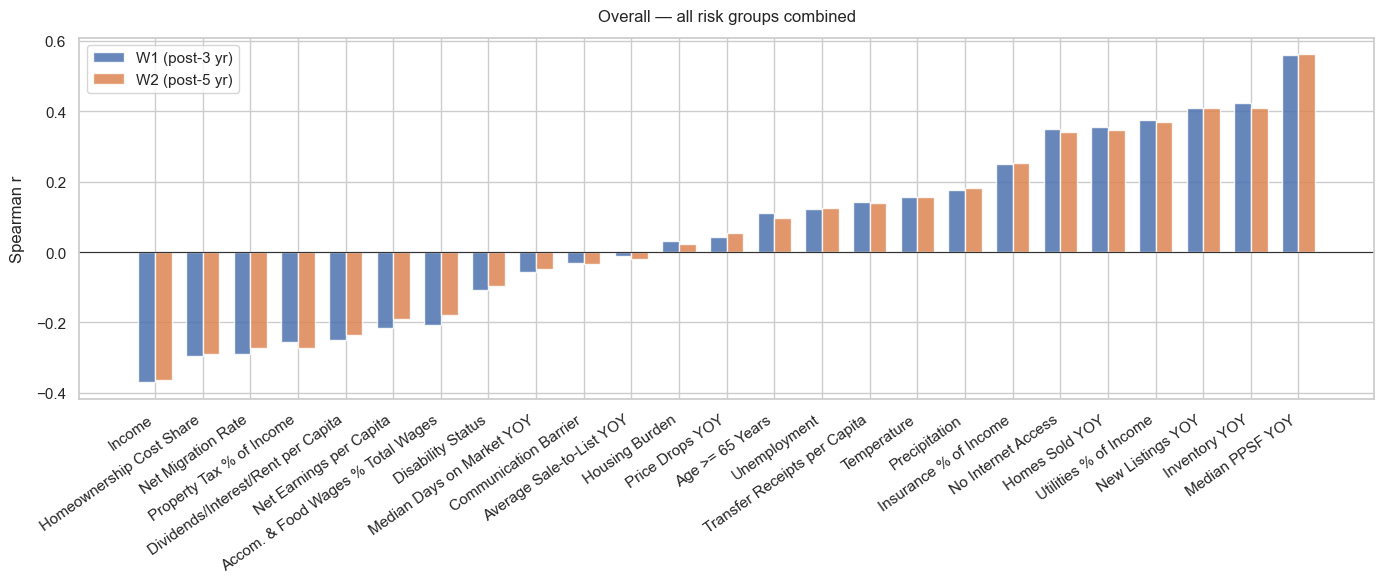

In [15]:
def plot_corr_comparison(corr1: pd.DataFrame, corr2: pd.DataFrame, title: str = "") -> None:
    merged = corr1[["label", "spearman_r"]].rename(columns={"spearman_r": "W1"}).merge(
        corr2[["label", "spearman_r"]].rename(columns={"spearman_r": "W2"}),
        on="label",
    )
    merged = merged.sort_values("W1")
    labels = merged["label"].tolist()
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(x - width / 2, merged["W1"], width, label="W1 (post-3 yr)", alpha=0.85)
    ax.bar(x + width / 2, merged["W2"], width, label="W2 (post-5 yr)", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.axhline(0, color="#333", linewidth=0.8)
    ax.set_ylabel("Spearman r")
    ax.set_title(title or "Spearman r with relative PPSF YOY position within NRI risk group")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_corr_comparison(corr1, corr2, "Overall — all risk groups combined")

## Correlations By NRI Risk Group

Repeat the Spearman analysis within each risk group separately to test whether the direction or magnitude of relationships differs across the risk spectrum.

In [16]:
def corr_by_group(analysis_df: pd.DataFrame, min_n: int = 10) -> pd.DataFrame:
    rows = []
    for group in RISK_ORDER:
        sub = analysis_df[analysis_df["risk_rating"] == group]
        for feat in FEATURES:
            vals = pd.to_numeric(sub[feat], errors="coerce")
            mask = sub["relative_position"].notna() & vals.notna()
            n = mask.sum()
            if n < min_n:
                rows.append({"risk_rating": group, "feature": feat,
                              "label": FEATURE_LABELS[feat], "n": n,
                              "spearman_r": np.nan, "p_value": np.nan})
                continue
            r, p = stats.spearmanr(sub.loc[mask, "relative_position"], vals[mask])
            rows.append({"risk_rating": group, "feature": feat,
                          "label": FEATURE_LABELS[feat], "n": n,
                          "spearman_r": r, "p_value": p})
    return pd.DataFrame(rows)


by_group1 = corr_by_group(a1)
by_group2 = corr_by_group(a2)

print("W1 — county-events per group:")
display(a1.groupby("risk_rating", observed=False).size().reindex(RISK_ORDER).rename("county_events"))
print("\nW2 — county-events per group:")
display(a2.groupby("risk_rating", observed=False).size().reindex(RISK_ORDER).rename("county_events"))

W1 — county-events per group:


risk_rating
Very Low               1174
Relatively Low         1112
Relatively Moderate     393
Relatively High         156
Very High                17
Name: county_events, dtype: int64


W2 — county-events per group:


risk_rating
Very Low               1192
Relatively Low         1119
Relatively Moderate     395
Relatively High         156
Very High                17
Name: county_events, dtype: int64

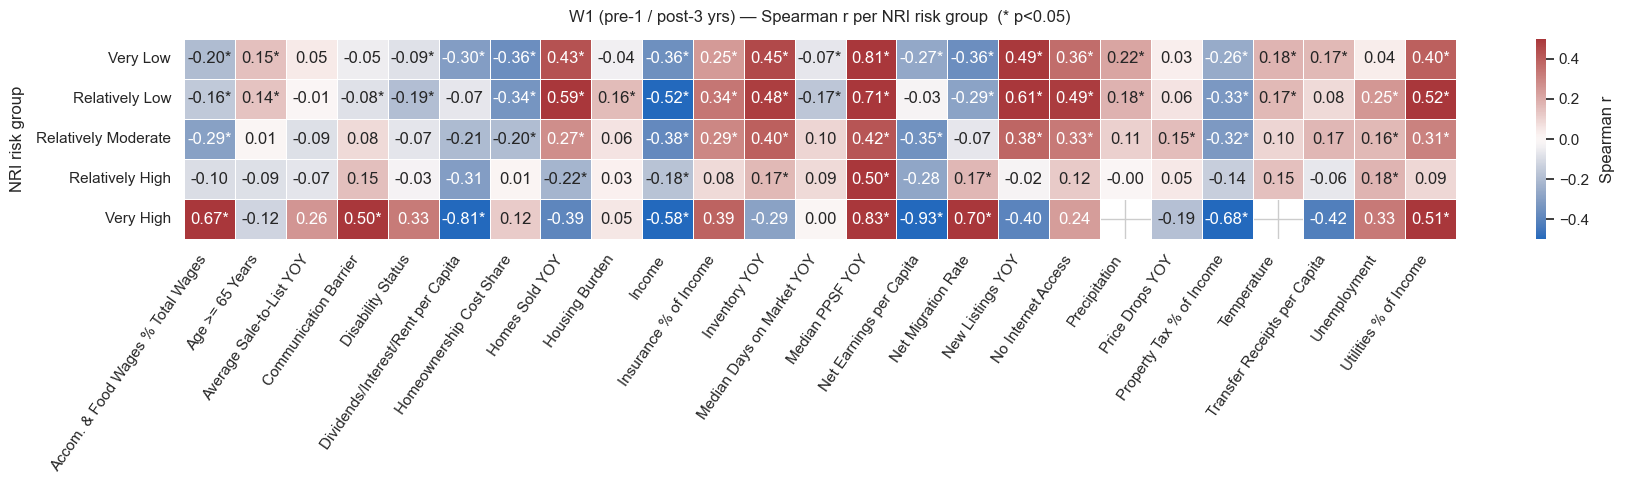

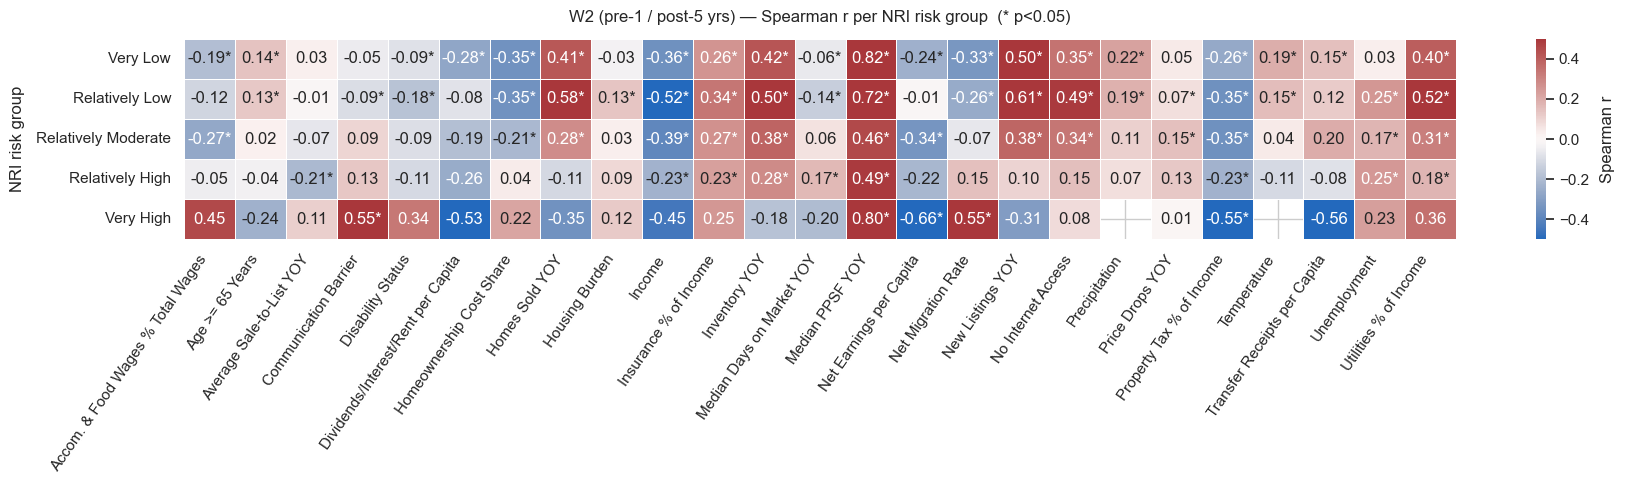

In [17]:
def plot_group_heatmap(by_group_df: pd.DataFrame, window_label: str) -> None:
    pivot = (
        by_group_df.pivot(index="risk_rating", columns="label", values="spearman_r")
        .reindex(RISK_ORDER)
    )

    # Significance mask — use NaN for cells below threshold
    sig_pivot = (
        by_group_df.pivot(index="risk_rating", columns="label", values="p_value")
        .reindex(RISK_ORDER)
    )
    annot = pivot.copy().astype(object)
    for row in annot.index:
        for col in annot.columns:
            r = pivot.loc[row, col]
            p = sig_pivot.loc[row, col]
            if pd.isna(r):
                annot.loc[row, col] = ""
            elif not pd.isna(p) and p < 0.05:
                annot.loc[row, col] = f"{r:.2f}*"
            else:
                annot.loc[row, col] = f"{r:.2f}"

    fig, ax = plt.subplots(figsize=(18, 5))
    sns.heatmap(
        pivot,
        cmap="vlag",
        center=0,
        vmin=-0.5,
        vmax=0.5,
        annot=annot,
        fmt="",
        linewidths=0.4,
        cbar_kws={"label": "Spearman r"},
        ax=ax,
    )
    ax.set_title(f"{window_label} — Spearman r per NRI risk group  (* p<0.05)")
    ax.set_xlabel("")
    ax.set_ylabel("NRI risk group")
    plt.xticks(rotation=55, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


plot_group_heatmap(by_group1, "W1 (pre-1 / post-3 yrs)")
plot_group_heatmap(by_group2, "W2 (pre-1 / post-5 yrs)")

### Ranked Within-Group Feature Correlations

For each NRI risk group, rank features by descending absolute Spearman correlation with relative PPSF YOY position. Bar direction keeps the signed correlation, while ordering is by absolute magnitude.


W1 - ranked features by risk group


,risk_rating,rank_within_group,label,n,spearman_r,abs_spearman_r
0,Relatively High,1.0,Median PPSF YOY,156,0.502894,0.502894
1,Relatively High,2.0,Dividends/Interest/Rent per Capita,35,-0.307003,0.307003
2,Relatively High,3.0,Net Earnings per Capita,35,-0.276190,0.276190
3,Relatively High,4.0,Homes Sold YOY,156,-0.224589,0.224589
4,Relatively High,5.0,Income,156,-0.177807,0.177807
...,...,...,...,...,...,...
120,Very Low,21.0,Communication Barrier,1174,-0.048014,0.048014
121,Very Low,22.0,Average Sale-to-List YOY,1082,0.045624,0.045624
122,Very Low,23.0,Housing Burden,1174,-0.039160,0.039160
123,Very Low,24.0,Unemployment,1174,0.035585,0.035585


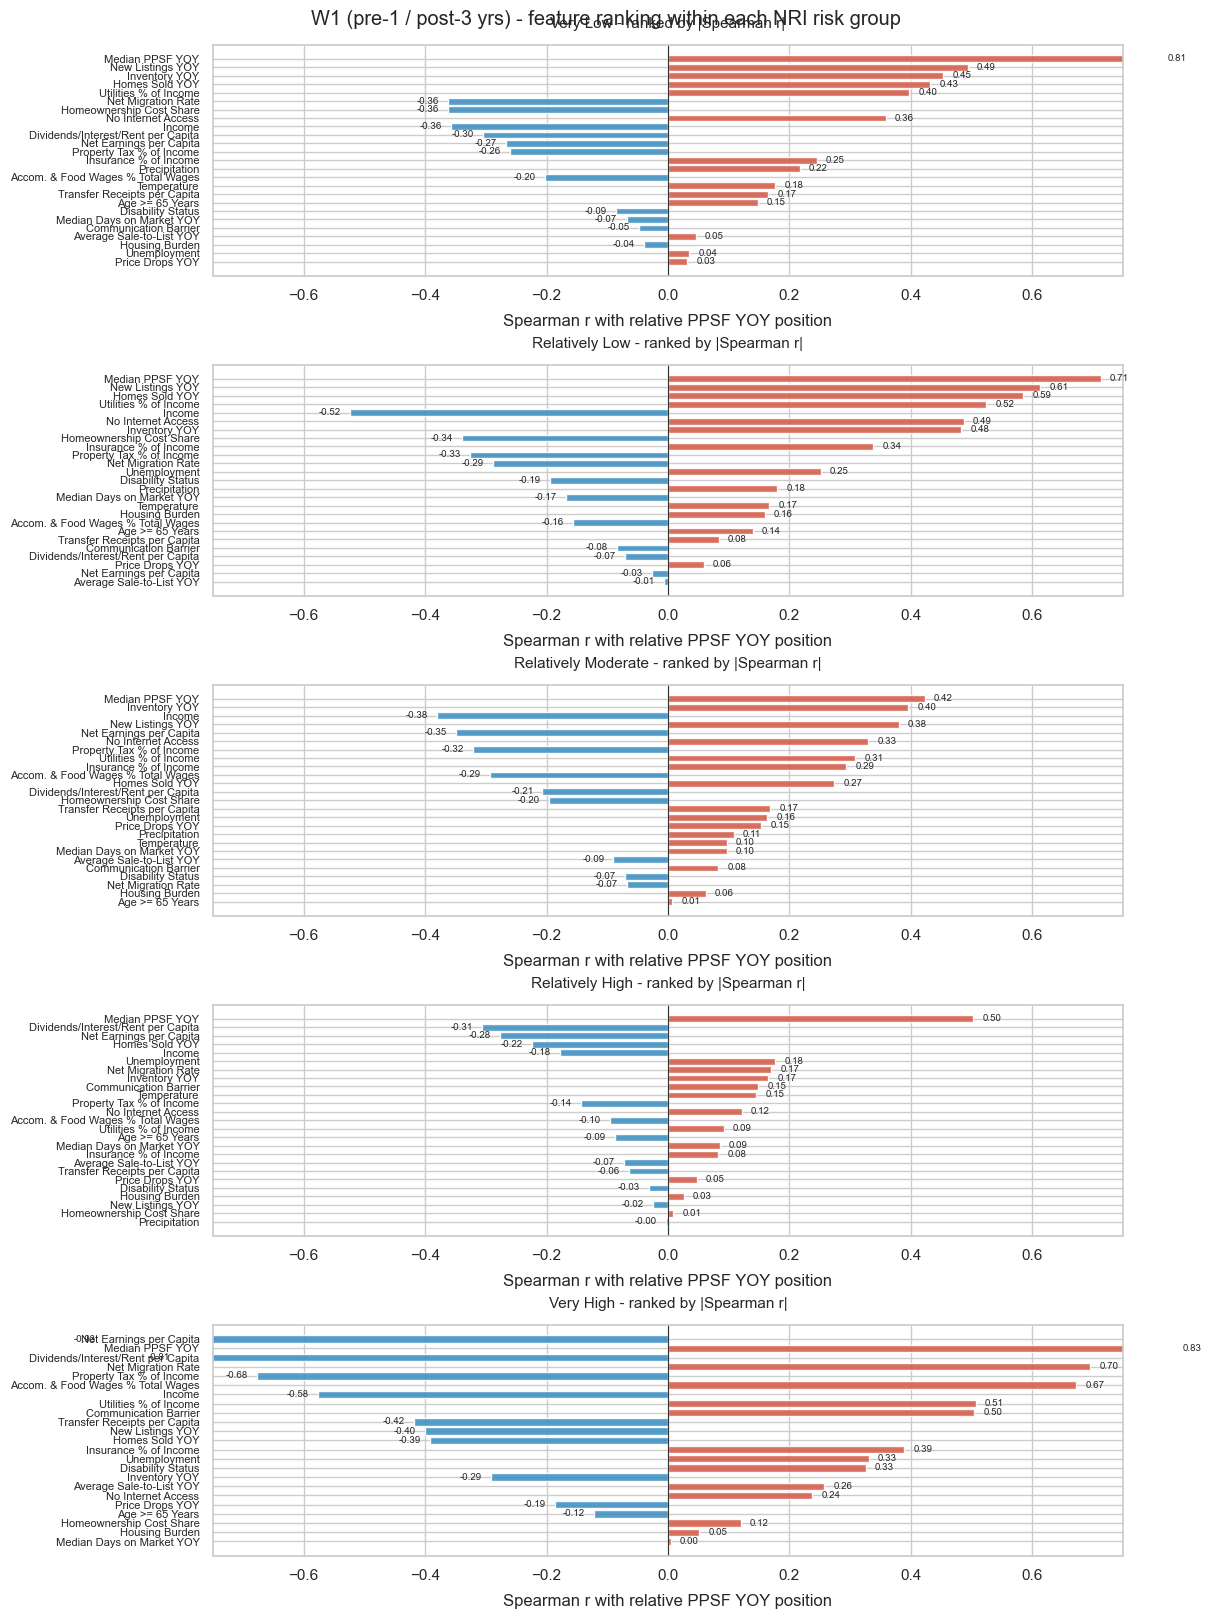

W2 - ranked features by risk group


,risk_rating,rank_within_group,label,n,spearman_r,abs_spearman_r
0,Relatively High,1.0,Median PPSF YOY,156,0.488916,0.488916
1,Relatively High,2.0,Inventory YOY,152,0.281761,0.281761
2,Relatively High,3.0,Dividends/Interest/Rent per Capita,35,-0.257143,0.257143
3,Relatively High,4.0,Unemployment,156,0.246137,0.246137
4,Relatively High,5.0,Income,156,-0.233042,0.233042
...,...,...,...,...,...,...
120,Very Low,21.0,Communication Barrier,1192,-0.050782,0.050782
121,Very Low,22.0,Price Drops YOY,1126,0.045676,0.045676
122,Very Low,23.0,Unemployment,1192,0.034056,0.034056
123,Very Low,24.0,Housing Burden,1192,-0.032690,0.032690


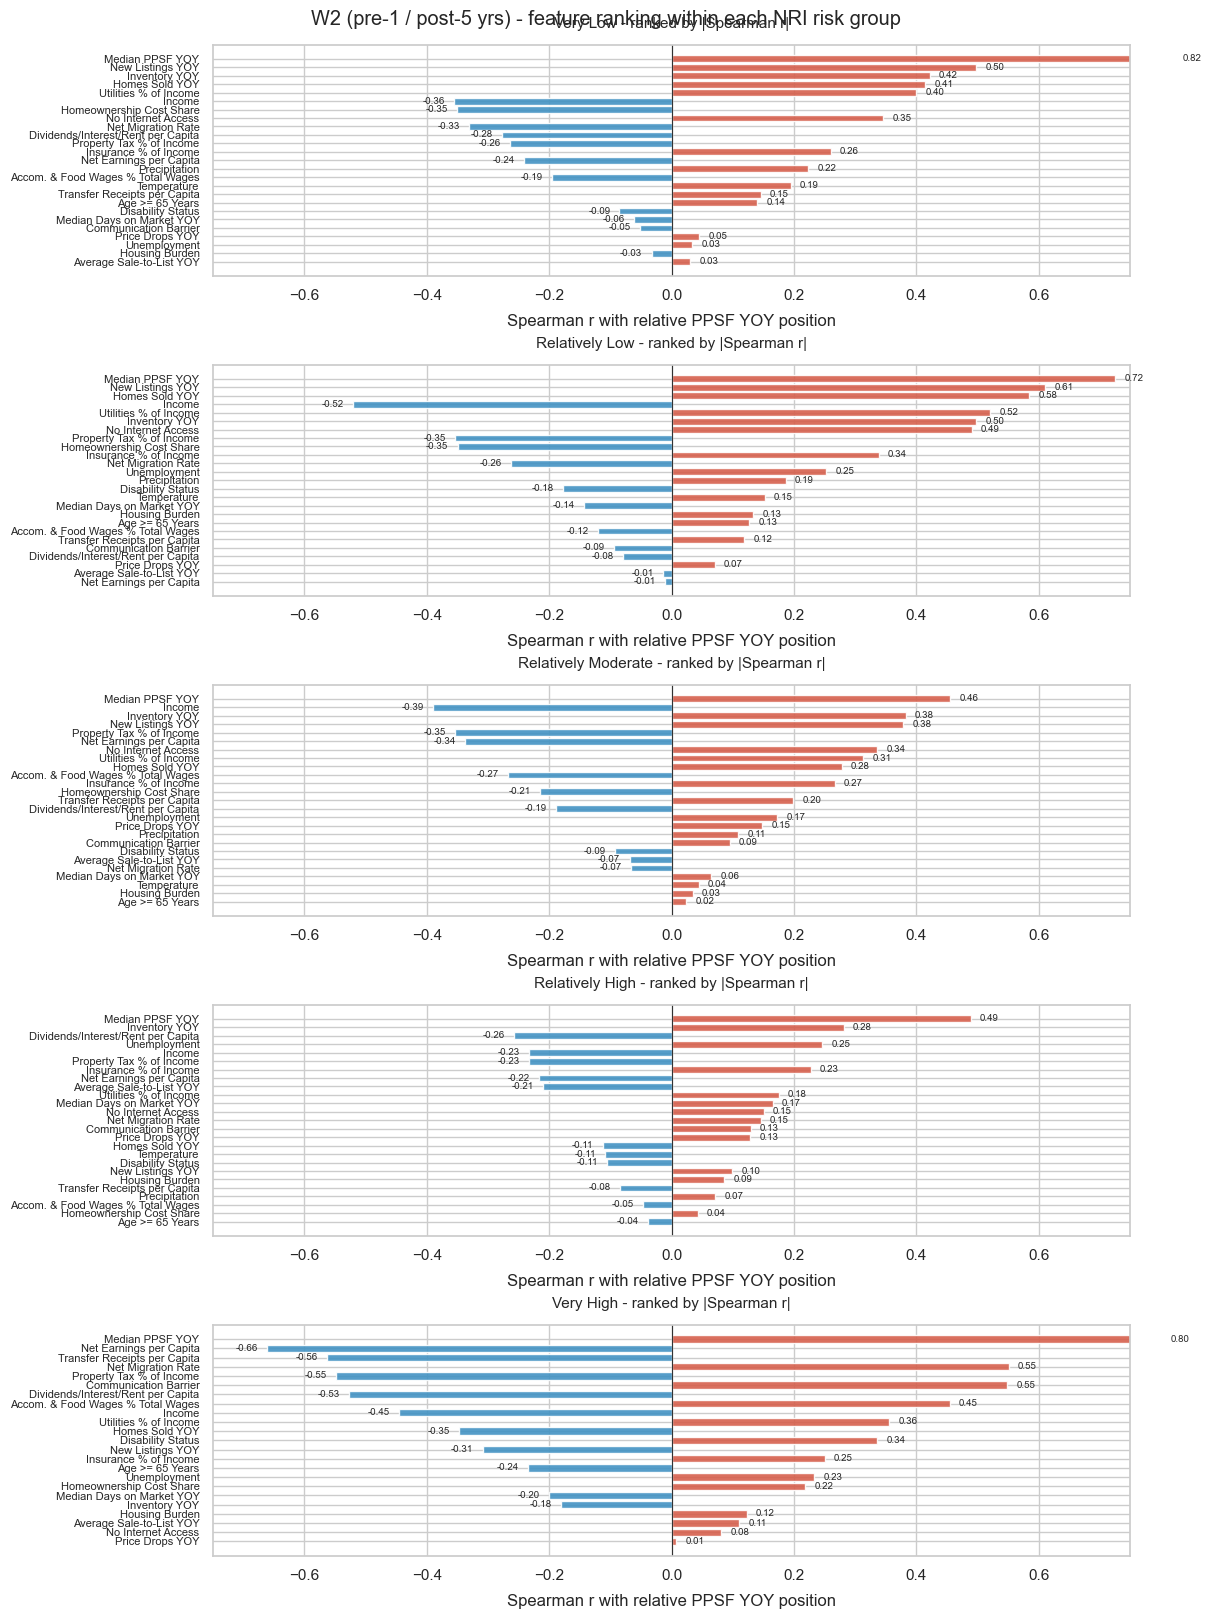

In [18]:
def ranked_group_correlations(by_group_df: pd.DataFrame) -> pd.DataFrame:
    ranked = by_group_df.copy()
    ranked["abs_spearman_r"] = ranked["spearman_r"].abs()
    ranked["rank_within_group"] = (
        ranked.groupby("risk_rating", observed=False)["abs_spearman_r"]
        .rank(method="first", ascending=False)
    )
    return ranked.sort_values(["risk_rating", "rank_within_group"]).reset_index(drop=True)


def plot_ranked_group_correlations(
    by_group_df: pd.DataFrame,
    window_label: str,
    *,
    top_n: int | None = None,
) -> None:
    ranked = ranked_group_correlations(by_group_df)
    if top_n is not None:
        ranked = ranked.loc[ranked["rank_within_group"] <= top_n].copy()

    group_count = len(RISK_ORDER)
    fig, axes = plt.subplots(group_count, 1, figsize=(12, 3.2 * group_count), constrained_layout=True)
    if group_count == 1:
        axes = [axes]

    for ax, group in zip(axes, RISK_ORDER):
        sub = ranked.loc[ranked["risk_rating"] == group].dropna(subset=["spearman_r"]).copy()
        sub = sub.sort_values("abs_spearman_r", ascending=False)
        if sub.empty:
            ax.set_visible(False)
            continue

        colors = np.where(sub["spearman_r"].ge(0), "#d6604d", "#4393c3")
        ax.barh(sub["label"], sub["spearman_r"], color=colors, alpha=0.9)
        ax.axvline(0, color="#333333", linewidth=0.8)
        ax.set_title(f"{group} - ranked by |Spearman r|", fontsize=11)
        ax.set_xlabel("Spearman r with relative PPSF YOY position")
        ax.set_ylabel("")
        ax.set_xlim(-0.75, 0.75)
        ax.invert_yaxis()
        ax.tick_params(axis="y", labelsize=8)

        for y_pos, (_, row) in enumerate(sub.iterrows()):
            if pd.isna(row["spearman_r"]):
                continue
            x = row["spearman_r"]
            ha = "left" if x >= 0 else "right"
            offset = 0.015 if x >= 0 else -0.015
            ax.text(x + offset, y_pos, f"{x:.2f}", va="center", ha=ha, fontsize=7)

    fig.suptitle(f"{window_label} - feature ranking within each NRI risk group", y=1.002)
    plt.show()


ranked_by_group1 = ranked_group_correlations(by_group1)
ranked_by_group2 = ranked_group_correlations(by_group2)

print("W1 - ranked features by risk group")
display(ranked_by_group1[["risk_rating", "rank_within_group", "label", "n", "spearman_r", "abs_spearman_r"]])
plot_ranked_group_correlations(by_group1, "W1 (pre-1 / post-3 yrs)")

print("W2 - ranked features by risk group")
display(ranked_by_group2[["risk_rating", "rank_within_group", "label", "n", "spearman_r", "abs_spearman_r"]])
plot_ranked_group_correlations(by_group2, "W2 (pre-1 / post-5 yrs)")

## Scatter Plots — Top Features vs Relative Position

The top 4 features by absolute Spearman |r| from W1 (overall), one panel per NRI risk group.

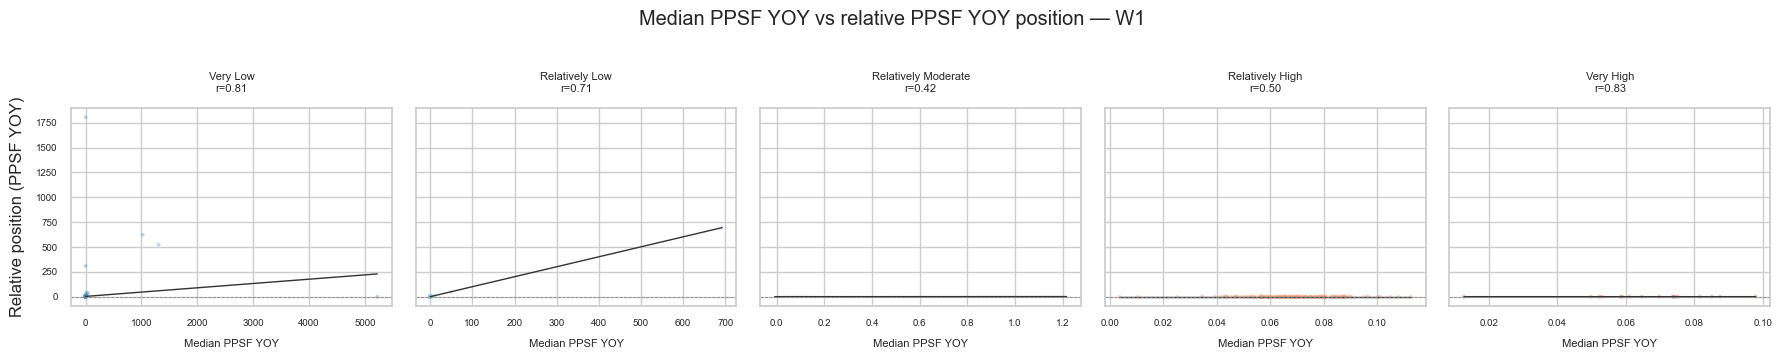

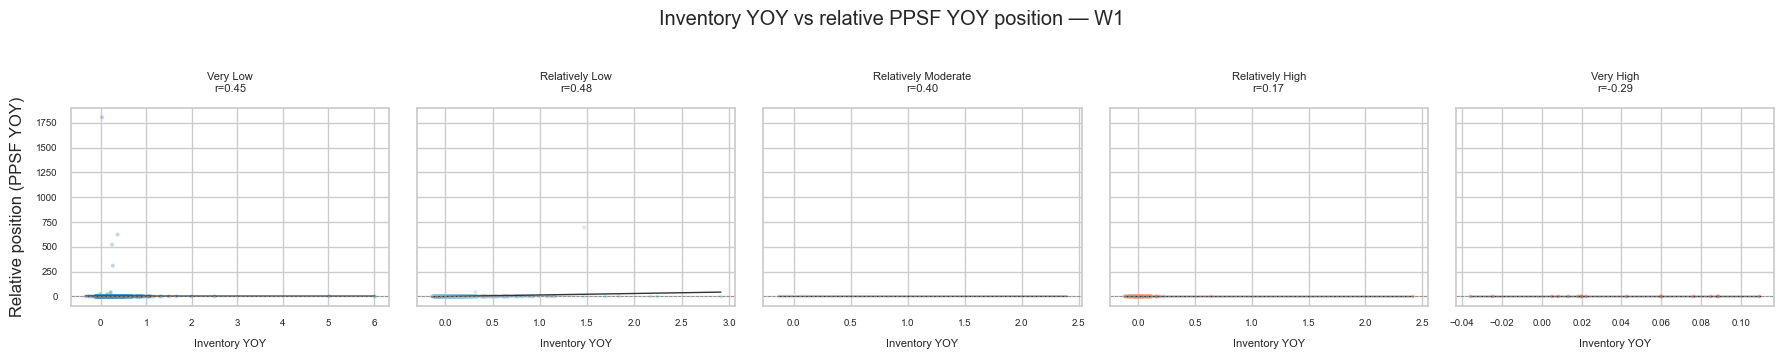

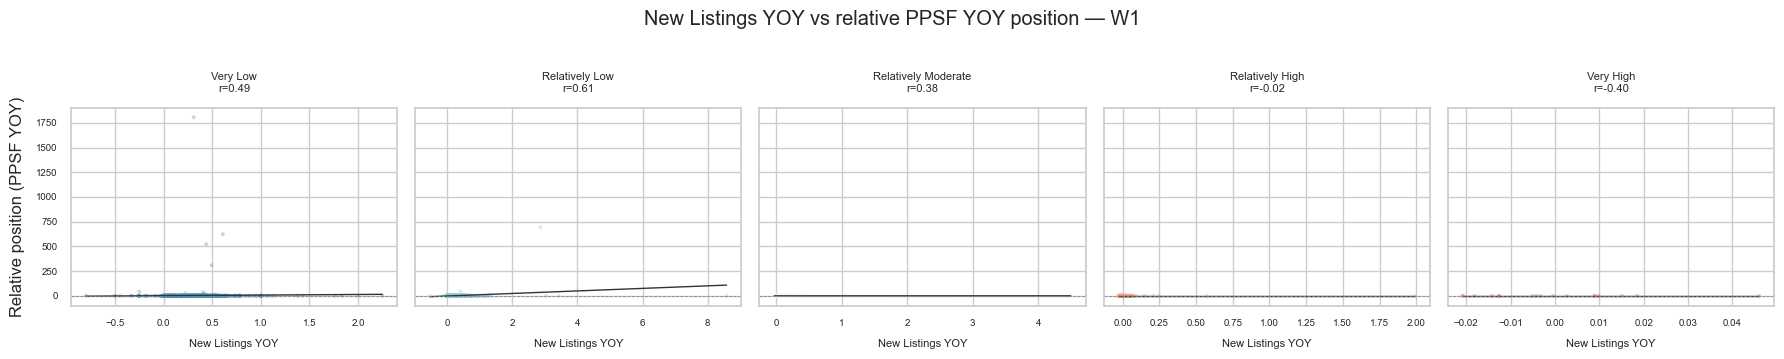

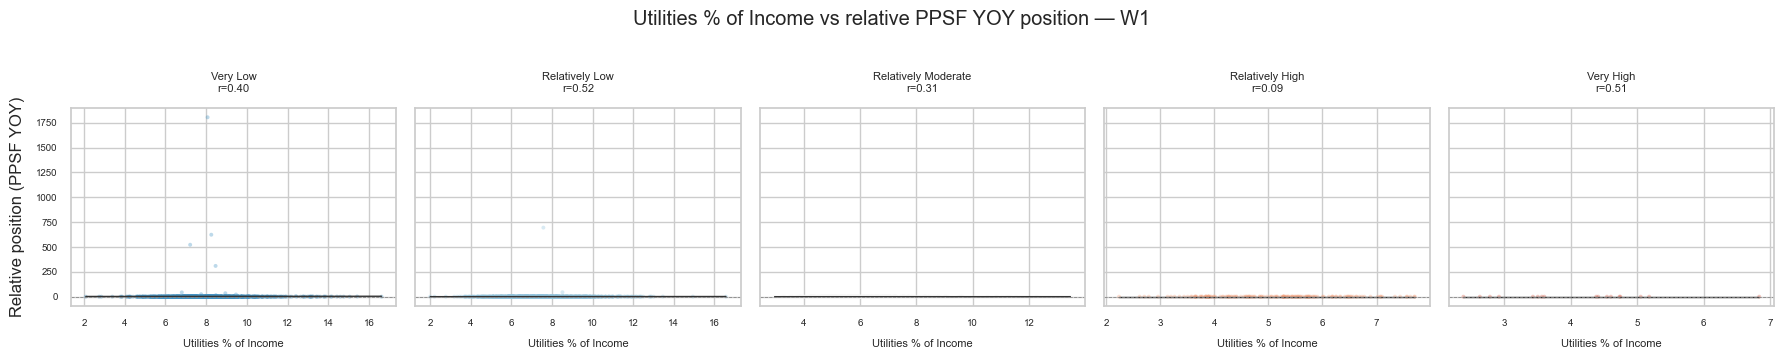

In [19]:
top_features = (
    corr1.assign(abs_r=corr1["spearman_r"].abs())
    .sort_values("abs_r", ascending=False)
    .head(4)["feature"]
    .tolist()
)

RISK_PALETTE = {
    "Very Low": "#4393c3",
    "Relatively Low": "#92c5de",
    "Relatively Moderate": "#f7f7f7",
    "Relatively High": "#f4a582",
    "Very High": "#d6604d",
}

for feat in top_features:
    label = FEATURE_LABELS[feat]
    fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=True)
    for ax, group in zip(axes, RISK_ORDER):
        sub = a1[a1["risk_rating"] == group].dropna(subset=[feat, "relative_position"])
        sub_feat = pd.to_numeric(sub[feat], errors="coerce")
        ax.scatter(
            sub_feat,
            sub["relative_position"],
            s=8,
            alpha=0.35,
            color=RISK_PALETTE[group],
            edgecolors="none",
        )
        if sub_feat.notna().sum() > 10:
            m, b = np.polyfit(sub_feat.dropna(), sub.loc[sub_feat.notna(), "relative_position"], 1)
            x_line = np.linspace(sub_feat.min(), sub_feat.max(), 100)
            ax.plot(x_line, m * x_line + b, color="#333", linewidth=1)
        ax.axhline(0, color="#888", linewidth=0.6, linestyle="--")
        r_val = by_group1.query(f"risk_rating == @group and feature == @feat")["spearman_r"]
        r_str = f"r={r_val.iloc[0]:.2f}" if not r_val.empty else ""
        ax.set_title(f"{group}\n{r_str}", fontsize=8)
        ax.set_xlabel(label, fontsize=8)
        ax.tick_params(labelsize=7)
    axes[0].set_ylabel("Relative position (PPSF YOY)")
    fig.suptitle(f"{label} vs relative PPSF YOY position — W1", y=1.02)
    plt.tight_layout()
    plt.show()

## Correlation Strength By Risk Group — Bar Summary

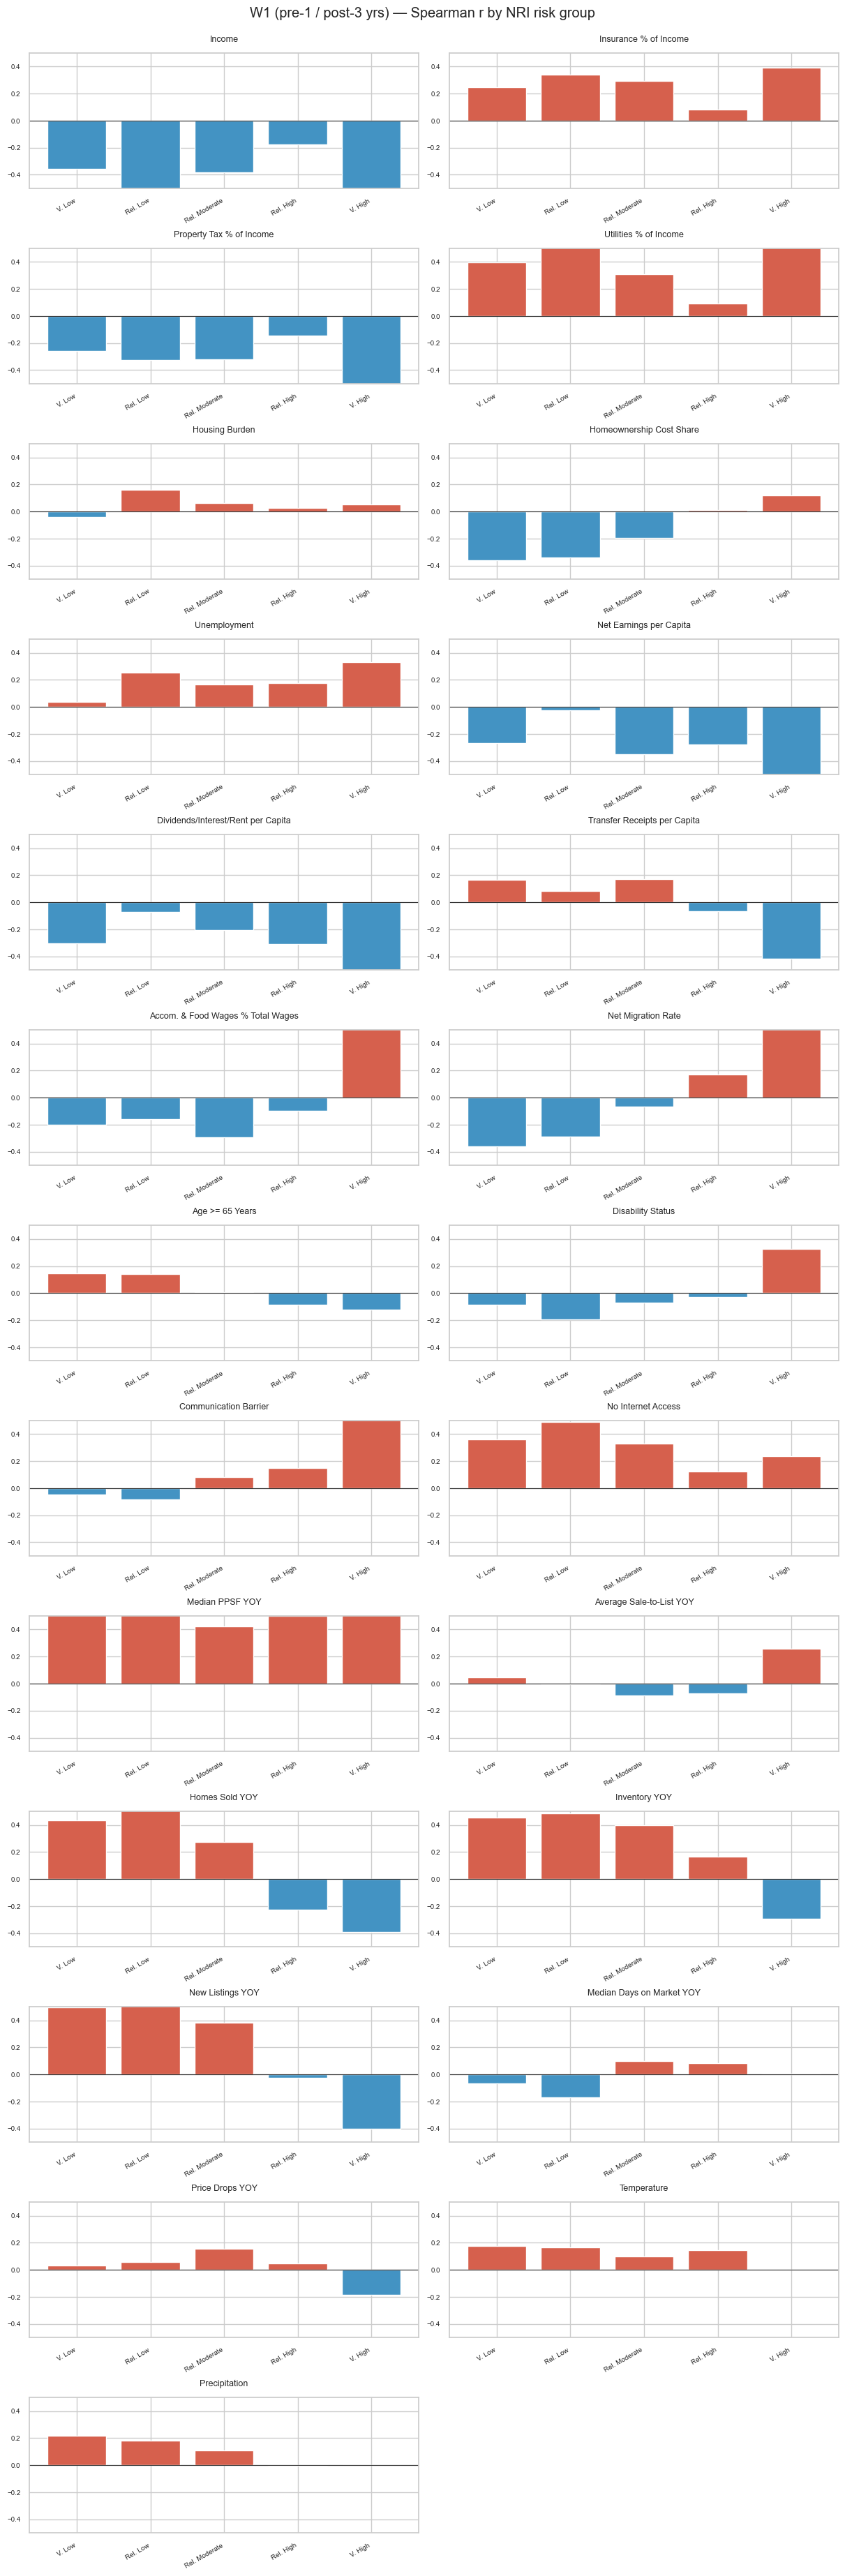

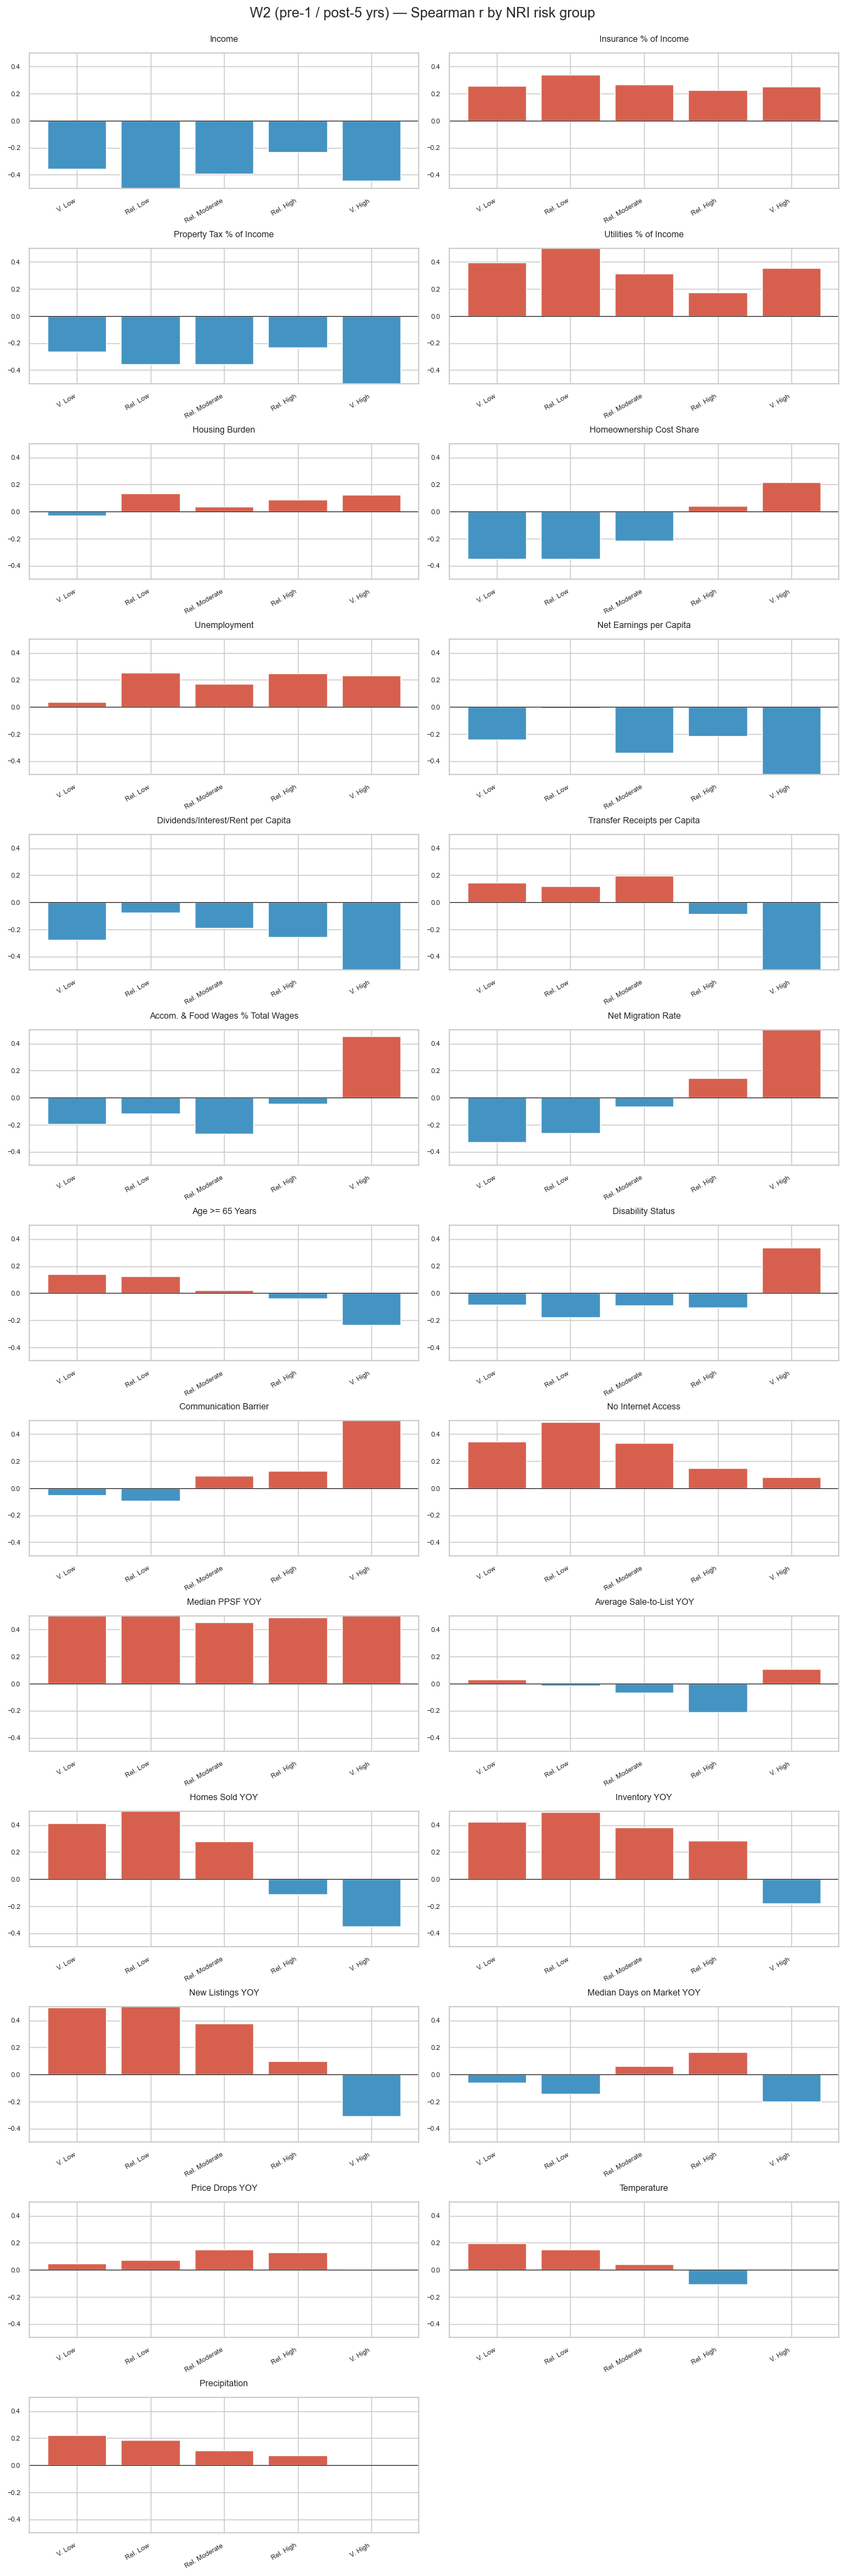

In [20]:
def plot_group_bars(by_group_df: pd.DataFrame, window_label: str) -> None:
    plot_data = by_group_df.copy()
    plot_data["risk_rating"] = pd.Categorical(plot_data["risk_rating"], categories=RISK_ORDER, ordered=True)

    n_features = len(FEATURES)
    n_cols = 2
    n_rows = int(np.ceil(n_features / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2.8 * n_rows), constrained_layout=True)

    for ax, feat in zip(axes.flatten(), FEATURES):
        sub = plot_data[plot_data["feature"] == feat].sort_values("risk_rating")
        colors = ["#d6604d" if v > 0 else "#4393c3" for v in sub["spearman_r"].fillna(0)]
        ax.bar(range(len(RISK_ORDER)), sub["spearman_r"].fillna(0), color=colors)
        ax.axhline(0, color="#333", linewidth=0.8)
        ax.set_xticks(range(len(RISK_ORDER)))
        ax.set_xticklabels([r.replace("Relatively ", "Rel. ").replace("Very ", "V. ") for r in RISK_ORDER],
                           fontsize=7, rotation=30, ha="right")
        ax.set_title(FEATURE_LABELS[feat], fontsize=9)
        ax.set_ylim(-0.5, 0.5)
        ax.tick_params(labelsize=7)

    for ax in axes.flatten()[n_features:]:
        fig.delaxes(ax)

    fig.suptitle(f"{window_label} — Spearman r by NRI risk group", y=1.01)
    plt.show()


plot_group_bars(by_group1, "W1 (pre-1 / post-3 yrs)")
plot_group_bars(by_group2, "W2 (pre-1 / post-5 yrs)")